In [67]:
import numpy as np
import torch 
import random
import os
from tqdm import tqdm 

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU
    
    # Force the use of deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For PyTorch 2.x+ (Handles scatter/gather ops)
    torch.use_deterministic_algorithms(True)
    
    # Crucial for GNNs: some scatter operations need an extra flag
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

seed_everything(42)

In [68]:
import pandas as pd 
from utils.graph_constructor import smiles_to_graph

In [69]:
molecule_net_data = pd.read_csv("./data/BBBP.csv").loc[:, ['smiles', 'p_np']]
molecule_net_data = molecule_net_data.rename(columns = {
  'smiles': 'smiles', 
  'p_np': 'label'
})

molecule_net_data

,smiles,label
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1
...,...,...
2045,C1=C(Cl)C(=C(C2=C1NC(=O)C(N2)=O)[N+](=O)[O-])Cl,1
2046,[C@H]3([N]2C1=C(C(=NC=N1)N)N=C2)[C@@H]([C@@H](...,1
2047,[O+]1=N[N](C=C1[N-]C(NC2=CC=CC=C2)=O)C(CC3=CC=...,1
2048,C1=C(OC)C(=CC2=C1C(=[N+](C(=C2CC)C)[NH-])C3=CC...,1


In [70]:
b3d8_data = pd.read_csv("./data/B3DB_classification_extended.tsv.gz", sep = '\t')
b3d8_data = b3d8_data.loc[:, ['SMILES', 'BBB+/BBB-']]

/tmp/ipykernel_43505/2542819401.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  b3d8_data = pd.read_csv("./data/B3DB_classification_extended.tsv.gz", sep = '\t')


In [71]:
b3d8_data['label'] = np.where(b3d8_data['BBB+/BBB-'] == 'BBB+', 1, 0) 
b3d8_data = b3d8_data.drop('BBB+/BBB-', axis =1)
b3d8_data = b3d8_data.rename(columns = {
  'SMILES': 'smiles', 
  'label': 'label'
})

In [72]:
data = pd.concat([molecule_net_data, b3d8_data], axis = 0) 
data

,smiles,label
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1
...,...,...
7802,c1ccc(CN(CC2=NCCN2)c2ccccc2)cc1,0
7803,CCOCCn1c(N2CCCN(C)CC2)nc2ccccc21,1
7804,CN1CCC(=C2c3ccccc3CC(=O)c3sccc32)CC1,1
7805,Cc1[nH]c(=O)c(C#N)cc1-c1ccncc1,0


In [73]:
data = data.drop_duplicates(['smiles'])

In [74]:
positive_samples = data[data['label'] == 1].shape[0] 
negative_samples = data[data['label'] == 0].shape[0] 

pos_weight = negative_samples / (positive_samples +negative_samples)

In [75]:
from pipeline.graph_pipeline import main 

train_loader, test_loader = main(batch_size = 1024, train_frac= 0.8) 

/home/pulkit/personal/programming/code/Python/bbbp graph classification/pipeline/graph_pipeline.py:26: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  b3d8_data = pd.read_csv(os.path.join(root, 'B3DB_classification_extended.tsv.gz'), sep = '\t')
[14:55:54] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] Explicit valence for atom # 6 N, 4, is greater than permitted


smiles conversion returned an empty molecule: O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3
O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3 could not be coverted to scaffold
smiles conversion returned an empty molecule: c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC
c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC could not be coverted to scaffold


[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:54] WARNING: not removing hydrogen atom without neighbors
[14:55:55] WARNING: not removing hydrogen atom without neighbors
[14:55:55] WARNING: not removing hydrogen atom without neighbors
[14:55:55] Explicit valence for atom # 11 N, 4, is greater than permitted


smiles conversion returned an empty molecule: Cc1nc(sc1)\[NH]=C(\N)N
Cc1nc(sc1)\[NH]=C(\N)N could not be coverted to scaffold
smiles conversion returned an empty molecule: s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N
s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N could not be coverted to scaffold


[14:55:55] Explicit valence for atom # 12 N, 4, is greater than permitted
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] WARNING: not removing hydrogen atom without neighbors
[14:55:55] WARNING: not removing hydrogen atom without neighbors
[14:55:55] Explicit valence for atom # 5 N, 4, is greater than permitted
[14:55:55] WARNING: not removing hydrogen atom without neighbors


...

[14:56:11] WARNING: not removing hydrogen atom without neighbors
[14:56:11] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:12] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not removing hydrogen atom without neighbors
[14:56:13] WARNING: not r

smiles conversion returned an empty molecule: s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N
smiles conversion error, skipping string s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N
smiles conversion returned an empty molecule: Cc1nc(sc1)\[NH]=C(\N)N
smiles conversion error, skipping string Cc1nc(sc1)\[NH]=C(\N)N


[14:56:15] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:56:15] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:56:15] WARNING: not removing hydrogen atom without neighbors
[14:56:15] WARNING: not removing hydrogen atom without neighbors
[14:56:15] WARNING: not removing hydrogen atom without neighbors
[14:56:15] WARNING: not removing hydrogen atom without neighbors
[14:56:15] Explicit valence for atom # 5 N, 4, is greater than permitted


smiles conversion returned an empty molecule: O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3
smiles conversion error, skipping string O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3
smiles conversion returned an empty molecule: c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC
smiles conversion error, skipping string c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC
smiles conversion returned an empty molecule: c1(cc(N\C(=[NH]\c2cccc(c2)CC)C)ccc1)CC
smiles conversion error, skipping string c1(cc(N\C(=[NH]\c2cccc(c2)CC)C)ccc1)CC
smiles conversion returned an empty molecule: C[N+]1(C)CCC[C@H](OC(=O)[C+](O)(c2ccccc2)c2ccccc2)C1
smiles conversion error, skipping string C[N+]1(C)CCC[C@H](OC(=O)[C+](O)(c2ccccc2)c2ccccc2)C1


[14:56:16] Explicit valence for atom # 10 C, 4, is greater than permitted


In [76]:
from pipeline.train_pipeline import TrainClassifier 

classifier = TrainClassifier(train_loader, 
                             test_loader, 
                             model_hidden_dim=64,
                             learning_rate=0.001, 
                             pos_weight=pos_weight) 

t_loss, v_loss = classifier.train_model(epochs = 50) 

/home/pulkit/personal/programming/code/Python/bbbp graph classification/model/gnn_model.py:49: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = gnn.GlobalAttention(nn.Sequential(


epoch 0: total loss: 0.3455209508538246
Validation run loss: 0.34602536261081696
epoch 1: total loss: 0.32441795989871025
Validation run loss: 0.341561958193779
epoch 2: total loss: 0.29763661324977875
Validation run loss: 0.2953241765499115
epoch 3: total loss: 0.27766576781868935
Validation run loss: 0.28459106385707855
epoch 4: total loss: 0.26915079541504383
Validation run loss: 0.3097563832998276
epoch 5: total loss: 0.27118865586817265
Validation run loss: 0.2876238077878952
epoch 6: total loss: 0.2610724326223135
Validation run loss: 0.27317795157432556
epoch 7: total loss: 0.2510264851152897
Validation run loss: 0.273097887635231
epoch 8: total loss: 0.24290859699249268
Validation run loss: 0.2609378397464752
epoch 9: total loss: 0.23926120437681675
Validation run loss: 0.28788433969020844
epoch 10: total loss: 0.25356429256498814
Validation run loss: 0.2629637122154236
epoch 11: total loss: 0.24225434847176075
Validation run loss: 0.25437960028648376
epoch 12: total loss: 0.23

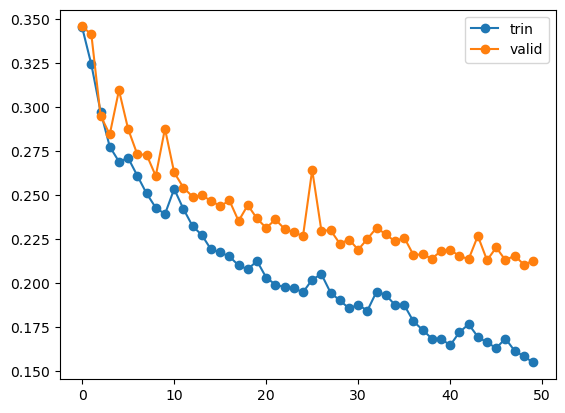

In [77]:
import matplotlib.pyplot as plt 

plt.plot(range(len(t_loss)), t_loss, marker = 'o', label = 'trin') 
plt.plot(range(len(v_loss)), v_loss, marker = 'o', label = 'valid') 
plt.legend()